In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.uniform import Uniform #initialize tensors with uniform distribution
from torch.utils.data import TensorDataset, DataLoader
import lightning as L
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Creating the Dataset

In [2]:
inputs = torch.tensor([[1., 0., 0., 0.],  # one-hot-encoding for Troll 2
                       [0., 1., 0., 0.],  # one-hot-encoding for is
                       [0., 0., 1., 0.],  # one-hot-encoding for great
                       [0., 0., 0., 1.]]) # one-hot-encoding for Gymkata

labels = torch.tensor([[0., 1., 0., 0.],
                       [0., 0., 1., 0.],
                       [0., 0., 0., 1.],
                       [0., 1., 0., 0.]])

In [3]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

## Build and train Word Embedding From scratch

In [4]:
class WordEmbedding(L.LightningModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        L.seed_everything(seed=42)

        min_value = -0.5
        max_value = 0.5

        # We initialize weights that feed 4 inputs (one for each unique word) into the 2 nodes in the hidden layer
        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        # Next we initialize the weights that come out of the hidden layer 
        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.loss = nn.CrossEntropyLoss()

    def forward(self, input):
        input = input[0]

        # For the top node in the hidden layer
        inputs_to_top_hidden = ((input[0] * self.input1_w1) +
                                (input[1] * self.input2_w1) +
                                (input[2] * self.input3_w1) +
                                (input[3] * self.input4_w1))

        # For the bottom node in the hidden layer
        inputs_to_bottom_hidden = ((input[0] * self.input1_w2) +
                                   (input[1] * self.input2_w2) +
                                   (input[2] * self.input3_w2) +
                                   (input[3] * self.input4_w2))
        
        
        # Now we compute the 4 output values from the 2 nodes in hidden layer
        output1 = ((inputs_to_top_hidden * self.output1_w1) +
                   (inputs_to_bottom_hidden * self.output1_w2))
        output2 = ((inputs_to_top_hidden * self.output2_w1) +
                   (inputs_to_bottom_hidden * self.output2_w2))
        output3 = ((inputs_to_top_hidden * self.output3_w1) +
                   (inputs_to_bottom_hidden * self.output3_w2))
        output4 = ((inputs_to_top_hidden * self.output4_w1) +
                   (inputs_to_bottom_hidden * self.output4_w2))

        # Now we need to concatenate the 4 output tensors so that we can run them through
        # the SoftMax function. However, because they are tensors  we use torch.stack()
        output_presoftmax = torch.stack([output1, output2, output3, output4])
        # nn.CrossEntropyLoss automatically applies softmax. If we want to actually use this network to predict the next word
        #       (instead of just using it for the Word Embedding values), then we'll need to apply the softmax() function
        #       ourselves (or just look to see what output value is largest).
        return(output_presoftmax)
    
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.1)
    
    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = self.loss(output_i, label_i[0])
        return loss

In [5]:
model = WordEmbedding()
print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Seed set to 42


Before optimization, the parameters are...
input1_w1 tensor(0.3800)
input1_w2 tensor(0.4200)
input2_w1 tensor(-0.1200)
input2_w2 tensor(0.4600)
input3_w1 tensor(-0.1100)
input3_w2 tensor(0.1000)
input4_w1 tensor(-0.2400)
input4_w2 tensor(0.2900)
output1_w1 tensor(0.4400)
output1_w2 tensor(-0.3700)
output2_w1 tensor(0.4300)
output2_w2 tensor(0.0900)
output3_w1 tensor(0.3700)
output3_w2 tensor(0.0700)
output4_w1 tensor(0.2400)
output4_w2 tensor(-0.0700)


In [6]:
data = {
    "w1": [model.input1_w1.item(), ## item() pulls out the tensor value as a float
           model.input2_w1.item(),
           model.input3_w1.item(),
           model.input4_w1.item()],
    "w2": [model.input1_w2.item(),
           model.input2_w2.item(),
           model.input3_w2.item(),
           model.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,0.415004,Troll2,input1
1,-0.117136,0.459306,is,input2
2,-0.109552,0.100895,great,input3
3,-0.243428,0.293641,Gymkata,input4


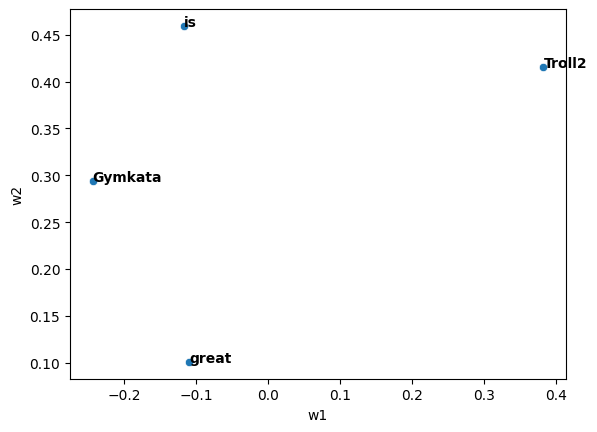

In [7]:
sns.scatterplot(data=df, x="w1", y="w2")

# Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [8]:
# we see that Gymkata and Troll2 are not similar at all. 

In [9]:
train = L.Trainer(max_epochs=100)
train.fit(model, train_dataloaders=dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | CrossEntropyLoss | 0      | train | 0    
  | other params | n/a              | 16     | n/a   | n/a  
------------------------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0     

Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 359.13it/s, v_num=3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 183.59it/s, v_num=3]


In [10]:
data = {
    "w1": [model.input1_w1.item(), ## item() pulls out the tensor value as a float
           model.input2_w1.item(),
           model.input3_w1.item(),
           model.input4_w1.item()],
    "w2": [model.input1_w2.item(),
           model.input2_w2.item(),
           model.input3_w2.item(),
           model.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.015884,1.941379,Troll2,input1
1,-2.181998,2.318640,is,input2
2,-2.028368,-2.161824,great,input3
3,1.691298,1.894238,Gymkata,input4


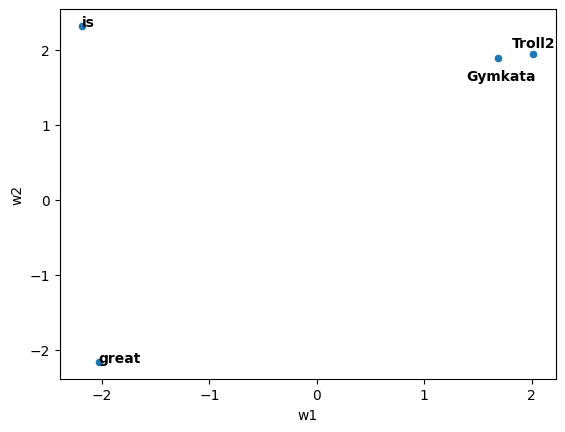

In [11]:
sns.scatterplot(data=df, x="w1", y="w2")

# NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
# they will be so close to each other that they will overlap and be unreadable.

## Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]+0.1, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## gymkata
plt.text(df.w1[3]-0.3, df.w2[3]-0.3, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [12]:
# Let's see what the model predicts

# First, let's create a softmax object
softmax = nn.Softmax(dim=0) # dim=0 applies softmax to rows, dim=1 applies softmax to columns


# print the predictions for "Troll2"
print(torch.round(softmax(model(torch.tensor([[1., 0., 0., 0.]]))),
                  decimals=2))

# print the predictions for "is"
print(torch.round(softmax(model(torch.tensor([[0., 1., 0., 0.]]))),
                  decimals=2))

# print the predictions for "great"
print(torch.round(softmax(model(torch.tensor([[0., 0., 1., 0.]]))),
                  decimals=2))

# print the predictions for "Gymkata"
print(torch.round(softmax(model(torch.tensor([[0., 0., 0., 1.]]))),
                  decimals=2))

tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 1., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 0., 1.], grad_fn=<RoundBackward1>)
tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)


In [13]:
# All tokens correctly predict the token that follows them.